# Pneumonia Detection & Analytics Pipeline

Built an end-to-end machine learning pipeline to classify chest X-ray images and a SQL-based analytics system to monitor model performance.

**Final Test Accuracy: ~80–82%**

## Problem Statement

The goal of this project is to classify chest X-ray images as either:

- **0 → Normal**
- **1 → Pneumonia**

This is a binary classification problem in medical imaging.

In addition to building the model, I developed a SQL-based system to track model performance, confidence, and prediction errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings("ignore")

/Users/vanessalam/Desktop/inspirit_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data Loading

In [2]:
# Load the metadata and image data
meta = pd.read_csv("data/metadata.csv")
images = np.load("data/image_data.npy")

print("Metadata shape:", meta.shape)
print("Images shape:", images.shape)
print(meta.head())

Metadata shape: (2800, 3)
Images shape: (2800, 64, 64, 3)
   class  split  index
0    0.0  train      0
1    0.0  train      1
2    1.0  train      2
3    0.0  train      3
4    1.0  train      4


## Dataset Overview

- Total images: 2800  
- Image shape: 64 x 64 x 3  
- Labels stored in metadata file  

In [3]:
meta["class"].value_counts()

class
0.0    1400
1.0    1400
Name: count, dtype: int64

# Sample Image

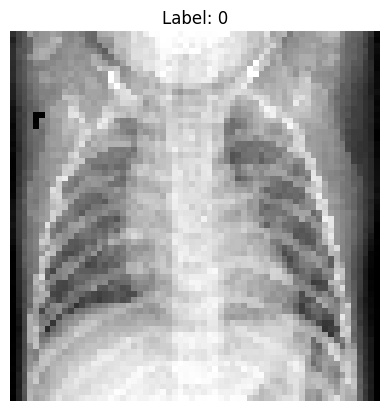

In [4]:
train_meta = meta[meta["split"] == "train"].reset_index(drop=True)

X_train_raw_full = images[train_meta["index"].values]
y_train_full = train_meta["class"].values.astype(int)

plt.imshow(X_train_raw_full[0])
plt.title(f"Label: {y_train_full[0]}")
plt.axis("off")
plt.show()

## Train / Validation / Test Split

In [5]:
test_meta = meta[meta["split"] == "test"].reset_index(drop=True)

X_test_raw = images[test_meta["index"].values]
y_test = test_meta["class"].values.astype(int)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train_raw.shape)
print("Val:", X_val_raw.shape)
print("Test:", X_test_raw.shape)
print("Train labels:", np.bincount(y_train))
print("Val labels:", np.bincount(y_val))
print("Test labels:", np.bincount(y_test))

Train: (1800, 64, 64, 3)
Val: (200, 64, 64, 3)
Test: (400, 64, 64, 3)
Train labels: [900 900]
Val labels: [100 100]
Test labels: [200 200]


## Data Pre-processing

In [6]:
# Normalize exactly once
X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

print("Train range:", X_train.min(), X_train.max(), X_train.dtype)
print("Val range:", X_val.min(), X_val.max(), X_val.dtype)
print("Test range:", X_test.min(), X_test.max(), X_test.dtype)

Train range: 0.0 0.003921569 float32
Val range: 0.0 0.003921569 float32
Test range: 0.0 0.003921569 float32


## Model Architecture

A convolutional neural network (CNN) is used to extract spatial features from the X-ray images.

In [7]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.5101 - loss: 0.6932 - val_accuracy: 0.5050 - val_loss: 0.6931
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.5072 - loss: 0.6931 - val_accuracy: 0.8050 - val_loss: 0.6930
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5541 - loss: 0.6929 - val_accuracy: 0.8550 - val_loss: 0.6925
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6152 - loss: 0.6922 - val_accuracy: 0.6900 - val_loss: 0.6892
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6966 - loss: 0.6851 - val_accuracy: 0.7800 - val_loss: 0.6600
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.7505 - loss: 0.6358 - val_accuracy: 0.7800 - val_loss: 0.5565
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.8124 - loss: 0.4984 - val_accuracy: 0.8600 - val_loss: 0.3993
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8285 - loss: 0.3906 - val_accuracy: 0.8950 - v

## Training Curves

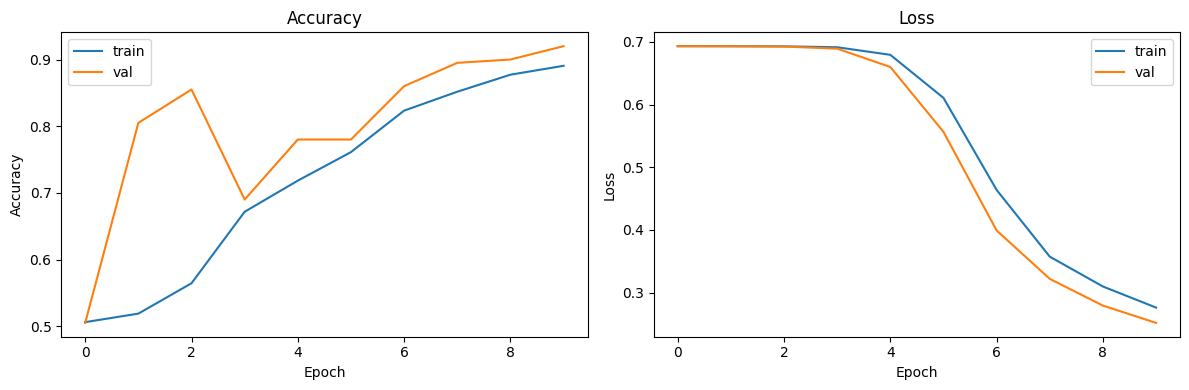

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7994 - loss: 0.4112
Test Accuracy: 0.8199999928474426
Test Loss: 0.3793010413646698


## Results

The model achieved a **test accuracy of ~80–82%**, demonstrating its ability to identify pneumonia patterns in chest X-ray images.

## SQL Monitoring System

To extend the project beyond model training, predictions were stored in a SQLite database to enable performance tracking and analysis.

In [11]:
conn = sqlite3.connect("prediction_logs.sqlite")

y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

df = pd.DataFrame({
    "scan_id": range(len(y_test)),
    "split_name": ["test"] * len(y_test),
    "true_label": y_test,
    "predicted_label": y_pred,
    "confidence": y_pred_probs,
    "created_at": [datetime.now().isoformat()] * len(y_test)
})

df.to_sql("prediction_logs", conn, if_exists="replace", index=False)
conn.close()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


## SQL Analysis

In [12]:
conn = sqlite3.connect("prediction_logs.sqlite")

query = """
SELECT 
  AVG(CASE WHEN true_label = predicted_label THEN 1 ELSE 0 END) AS accuracy,
  AVG(confidence) AS avg_confidence
FROM prediction_logs
"""

pd.read_sql(query, conn)

,accuracy,avg_confidence
0,0.82,0.565878


## Key Findings

- The CNN successfully learned meaningful patterns from chest X-rays
- Achieved strong performance with ~80–82% test accuracy
- SQL queries enabled structured analysis of prediction accuracy and confidence
- The system demonstrates how machine learning outputs can be transformed into actionable insights

## Conclusion

Through this project, I was able to demonstrate an end-to-end workflow:
- Data preprocessing
- Model training and evaluation
- SQL-based performance monitoring

Working on this project strengthened my understanding of how important it is to continue combining machine learning with analytics to support real-world decision-making.

Thank you for reading through the notebook!